# Sprint 1 - Exploratory Data Analysis - by Chris as of 13.04.2026 10:00

### Business question: 

### What factors contribute to or justify a higher compensation for developers in the DACH region?  

In this EDA:

1. A developer is a person who explicit answered that s/he is a developer by profession in the survey.

2. S/he is currently employed, or is an independent contractor, freelancer, or self-employed.

3. Factors refer to actions which a developer can decide and act upon by his or her own.

    - Examples of factors of interest in this EDA are:
        - The highest education level achieved.
        - Did s/he learn new programming techiques or programming languages last year.
        - Did s/he learn AI programming or AI-enabled tooling last year.
        - Nature of company s/he chooses e.g. size of his/her current employer, industry the company is in etc.
        - Nature of work s/he acts on e.g. people management besides coding, influence on purchase decisions etc.
        - ...

    - Examples of factors **NOT** of interest in this EDA are:
        - Country a developer is located - this is not something s/he can change easily.
        - Age - this is not something s/he can change, although it can have an effect on compensation.

4.  The DACH region refers to Germany (D), Austria (A) and Switzerland (CH)

    - It is being chosen as they are German-speaking countries and form a unique job market.
    - Combined it has the 2nd largest number of responses to the survey with compensation specified.
    - It is where the team members of this project team are located.

5.  Compensation
    - The yearly compensation converted to USD "ConvertedCompYearly" will be used as the measure.
    - This is because Switzerland has its own currency different from Germany and Austria using Euros.

---

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from ydata_profiling import ProfileReport   # problem running with python 3.12 and later
import missingno as msno

In [2]:
# assumes data located in a subfolder of the directory where this script is located
data_path = Path.cwd().joinpath("./data")

# data file containing survey results
results_file = data_path.joinpath("survey_results_public.csv")

In [3]:
# load results to data frame
df_results = pd.read_csv(results_file, low_memory=False)

In [4]:
# info on data frame
print("*** Info on data frame")
print(df_results.info())

*** Info on data frame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB
None


In [5]:
# number of rows and columns aka shape
print("*** Shape: number of rows and columns")
print(df_results.shape)         

*** Shape: number of rows and columns
(49191, 172)


## Interim findings
-------------------

Given the huge number of columns and rows, it is important to focus on those that are relevant for the business question first in this EDA.

Next is to get a first impression on the summary statistics of the data set, as well as a first impression on the nature of the values in it.

---


In [6]:
# summary statistics
print("*** Summary statistics")
print(df_results.describe().to_string())

*** Summary statistics
         ResponseId       WorkExp     YearsCode  TechEndorse_1  TechEndorse_2  TechEndorse_3  TechEndorse_4  TechEndorse_5  TechEndorse_6  TechEndorse_7  TechEndorse_8  TechEndorse_9  TechEndorse_13  TechOppose_1  TechOppose_2  TechOppose_3  TechOppose_5  TechOppose_7  TechOppose_9  TechOppose_11  TechOppose_13  TechOppose_16  TechOppose_15  JobSatPoints_1  JobSatPoints_2  JobSatPoints_3  JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  JobSatPoints_8  JobSatPoints_9  JobSatPoints_10  JobSatPoints_11  JobSatPoints_13  JobSatPoints_14  JobSatPoints_15  JobSatPoints_16  ToolCountWork  ToolCountPersonal     CompTotal  SO_Actions_1  SO_Actions_16  SO_Actions_3  SO_Actions_4  SO_Actions_5  SO_Actions_6  SO_Actions_9  SO_Actions_7  SO_Actions_10  SO_Actions_15  ConvertedCompYearly        JobSat
count  49191.000000  42893.000000  43042.000000   35975.000000   35975.000000   35975.000000   35975.000000   35975.000000   35975.000000   35975.000000   35975.0

## Interim findings
-------------------

Rows with invalid data found.  Examples:

1.  WorkExp - 100 years of work experience is probably invalid.
2.  YearsCode - 100 years of coding experience is probably invalid.
3.  ToolCountWork - using 10000 tools at work is probably invalid.
4.  ToolCountPersonal - using 10000 tools in personal projects is probably invalid.

We shall see what is the impact on the number of rows if invalid rows along the line of these first symptoms are removed from the analysis later.

---

In [7]:
# Check data types
print("*** Data types")
print(df_results.dtypes.to_string())

*** Data types
ResponseId                                    int64
MainBranch                                   object
Age                                          object
EdLevel                                      object
Employment                                   object
EmploymentAddl                               object
WorkExp                                     float64
LearnCodeChoose                              object
LearnCode                                    object
LearnCodeAI                                  object
AILearnHow                                   object
YearsCode                                   float64
DevType                                      object
OrgSize                                      object
ICorPM                                       object
RemoteWork                                   object
PurchaseInfluence                            object
TechEndorseIntro                             object
TechEndorse_1                               float

In [8]:
# list first records
print("*** First records")
print(df_results.head(10).to_string())

*** First records
   ResponseId                      MainBranch              Age                                                 EdLevel                                            Employment                                                                                           EmploymentAddl  WorkExp                                                                              LearnCodeChoose                                                                                                                                                                                                                                                                                                                                                                                                               LearnCode                                                                                                   LearnCodeAI                                                                                     

In [9]:
# list last records
print("*** Last records")
print(df_results.tail(10).to_string())

*** Last records
       ResponseId                                                                             MainBranch              Age                                                 EdLevel                                            Employment                                                            EmploymentAddl  WorkExp                                                                            LearnCodeChoose                                                                                                                                                                                                                                                                                                                                                                                                                               LearnCode                                                                             LearnCodeAI                                                                  

In [10]:
# check number of rows with invalid ConvertedCompYearly
col = 'ConvertedCompYearly'
mask = (
    df_results[col].isna()
)
count = mask.sum()
print("Number of rows with NaN as value in ConvertedCompYearly:", count)

# check if there can be other invalid values in ConvertedCompYearly other than NaN
mask = (
    df_results[col].eq(0)                               # numeric 0 or 0.0
    | (df_results[col].astype(str).str.strip() == '')   # empty string or spaces
)

count = mask.sum()
print("Number of rows with 0 or empty space as value in ConvertedCompYearly:", count)

Number of rows with NaN as value in ConvertedCompYearly: 25244
Number of rows with 0 or empty space as value in ConvertedCompYearly: 0


## Interim findings
-------------------

Target prediction value ConvertedCompYearly can be undefined.  The are always indicated by the value NaN.  Rows with undefined compensation values should be skipped when using supervised learning models later.

Object fields can contain non-numeric text separated by separators.  Such text are entered free-form according to the survey schema (type = TE).  Classifying and tallying free-form text will not be done in this EDA.  Word clouds will be used instead to see if there are first insights in them.  See the section on ydata-profiling.

Next is to check if there are other missing values in the data set.

---

In [11]:
# Check the number of missing values across the whole original dataset, and list them in percentage
print("*** Missing values in percentage")
print((df_results.isnull().mean() * 100).round(2).to_string())

*** Missing values in percentage
ResponseId                                   0.00
MainBranch                                   0.00
Age                                          0.00
EdLevel                                      2.12
Employment                                   1.73
EmploymentAddl                               8.77
WorkExp                                     12.80
LearnCodeChoose                              4.74
LearnCode                                   31.78
LearnCodeAI                                  8.11
AILearnHow                                  42.56
YearsCode                                   12.50
DevType                                     11.20
OrgSize                                     30.52
ICorPM                                      32.42
RemoteWork                                  31.33
PurchaseInfluence                           23.89
TechEndorseIntro                            23.65
TechEndorse_1                               26.87
TechEndorse_2    

In [12]:
# list columns with more than 50% missing values
na_pct = (df_results.isnull().mean() * 100).round(2)
high_na = na_pct[na_pct > 50]
print(high_na.to_string())

TechEndorse_13_TEXT                   95.92
TechOppose_15_TEXT                    96.65
JobSatPoints_15_TEXT                  98.65
LanguageAdmired                       52.29
LanguagesHaveEntry                    91.91
LanguagesWantEntry                    93.60
DatabaseWantToWorkWith                59.88
DatabaseAdmired                       64.84
DatabaseHaveEntry                     95.63
DatabaseWantEntry                     96.88
PlatformHaveWorkedWith                50.69
PlatformWantToWorkWith                60.53
PlatformAdmired                       63.77
PlatformHaveEntry                     91.96
PlatformWantEntry                     93.70
WebframeHaveWorkedWith                53.26
WebframeWantToWorkWith                64.14
WebframeAdmired                       68.07
WebframeHaveEntry                     93.30
WebframeWantEntry                     94.65
DevEnvsWantToWorkWith                 58.09
DevEnvsAdmired                        60.37
DevEnvHaveEntry                 

<Axes: >

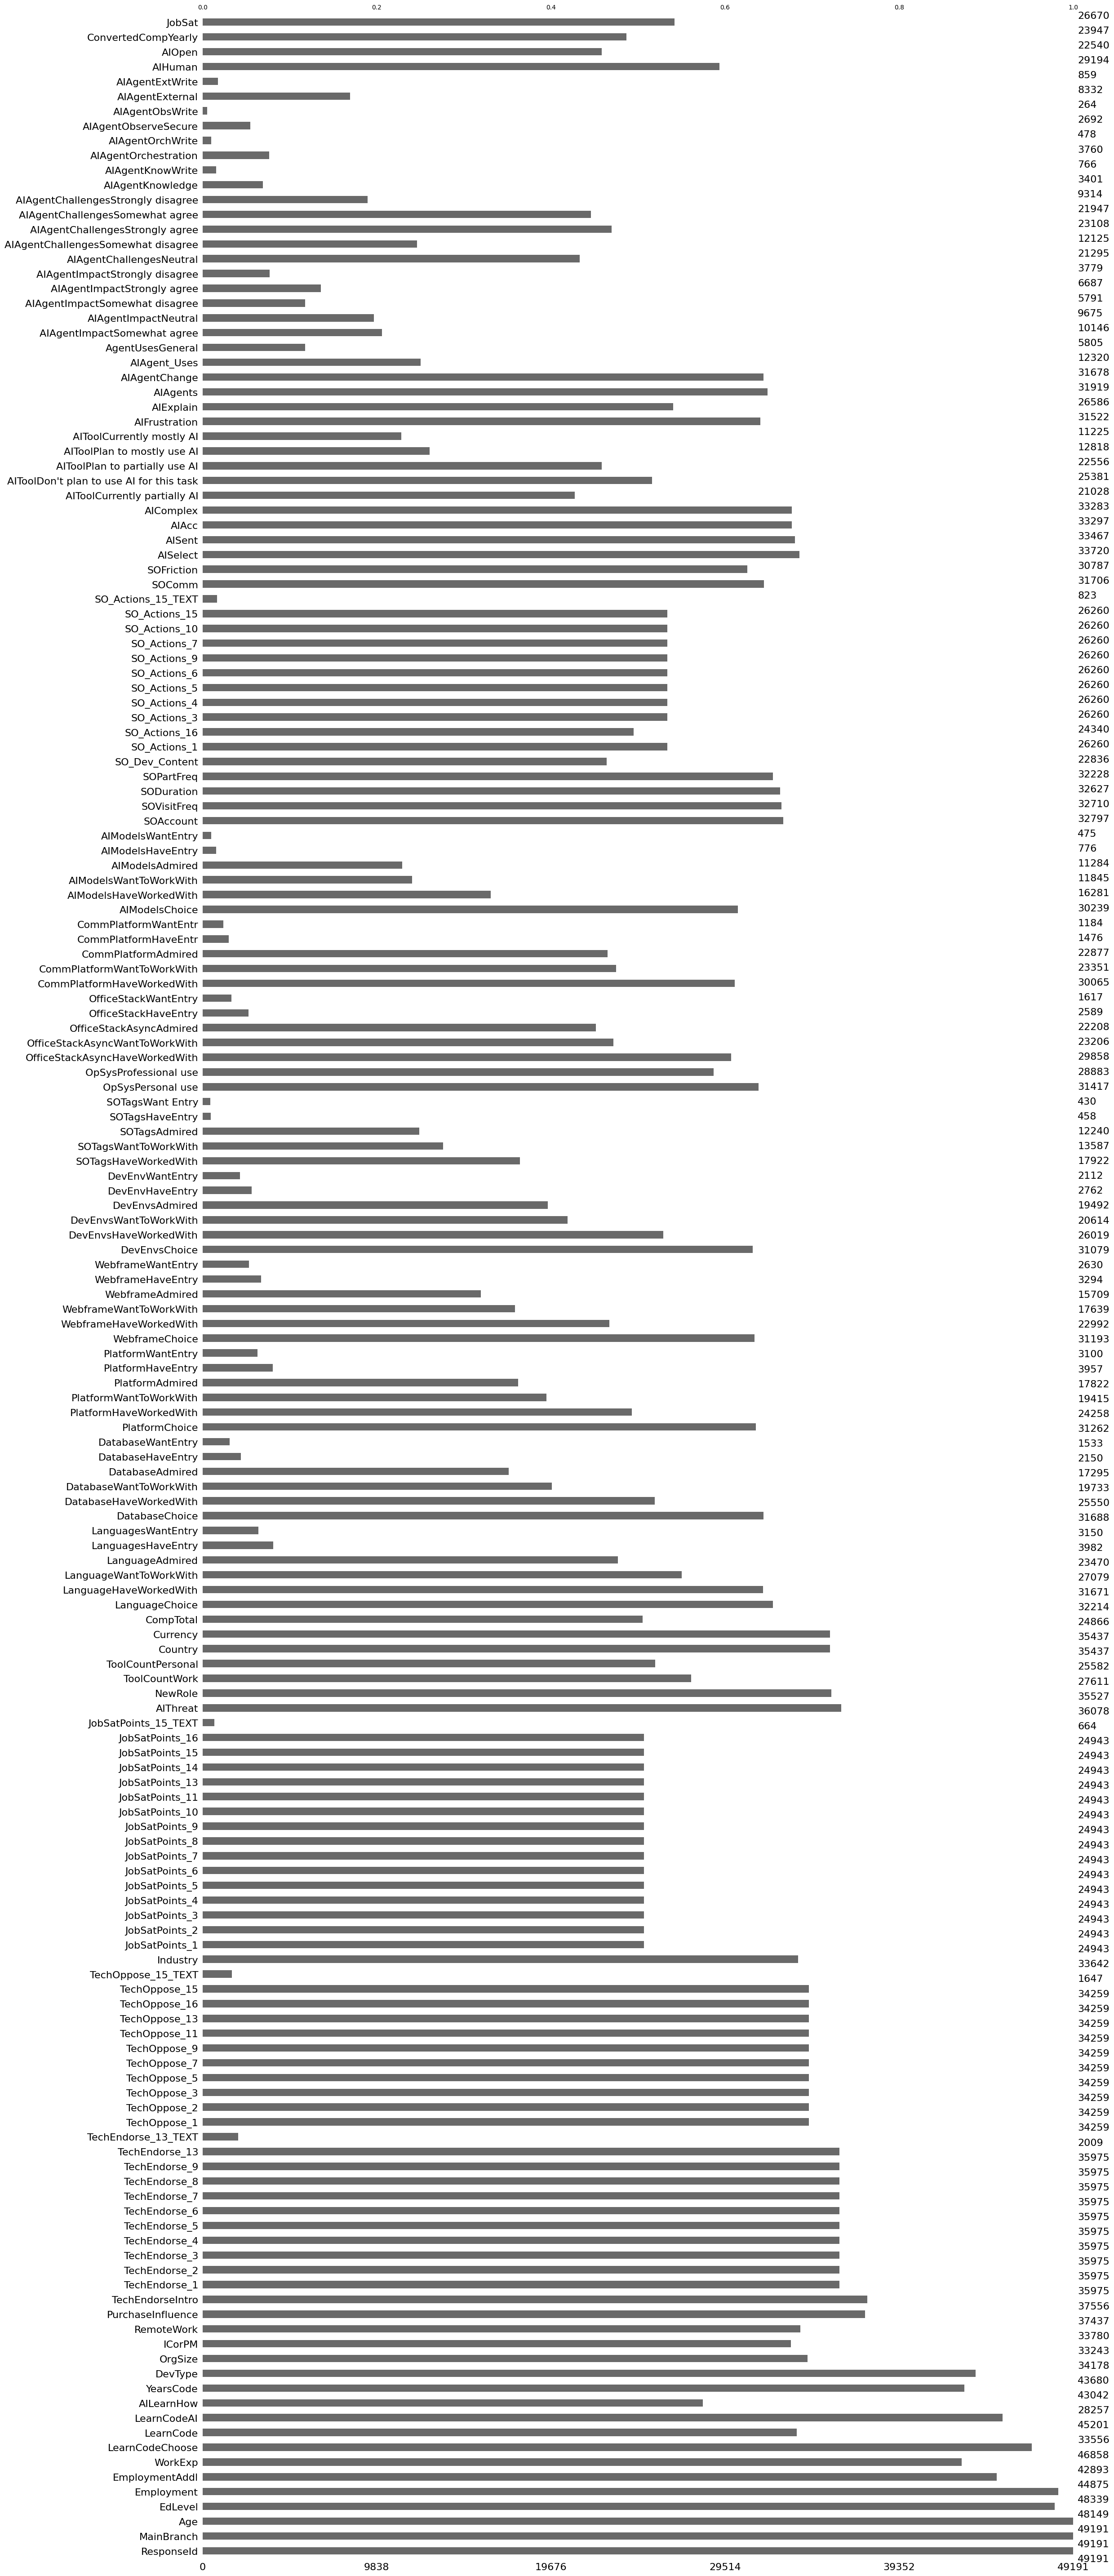

In [13]:
# summary bar showing rows with response in percentage (on top) and in absolute number (at the right)
msno.bar(df_results)

<Axes: >

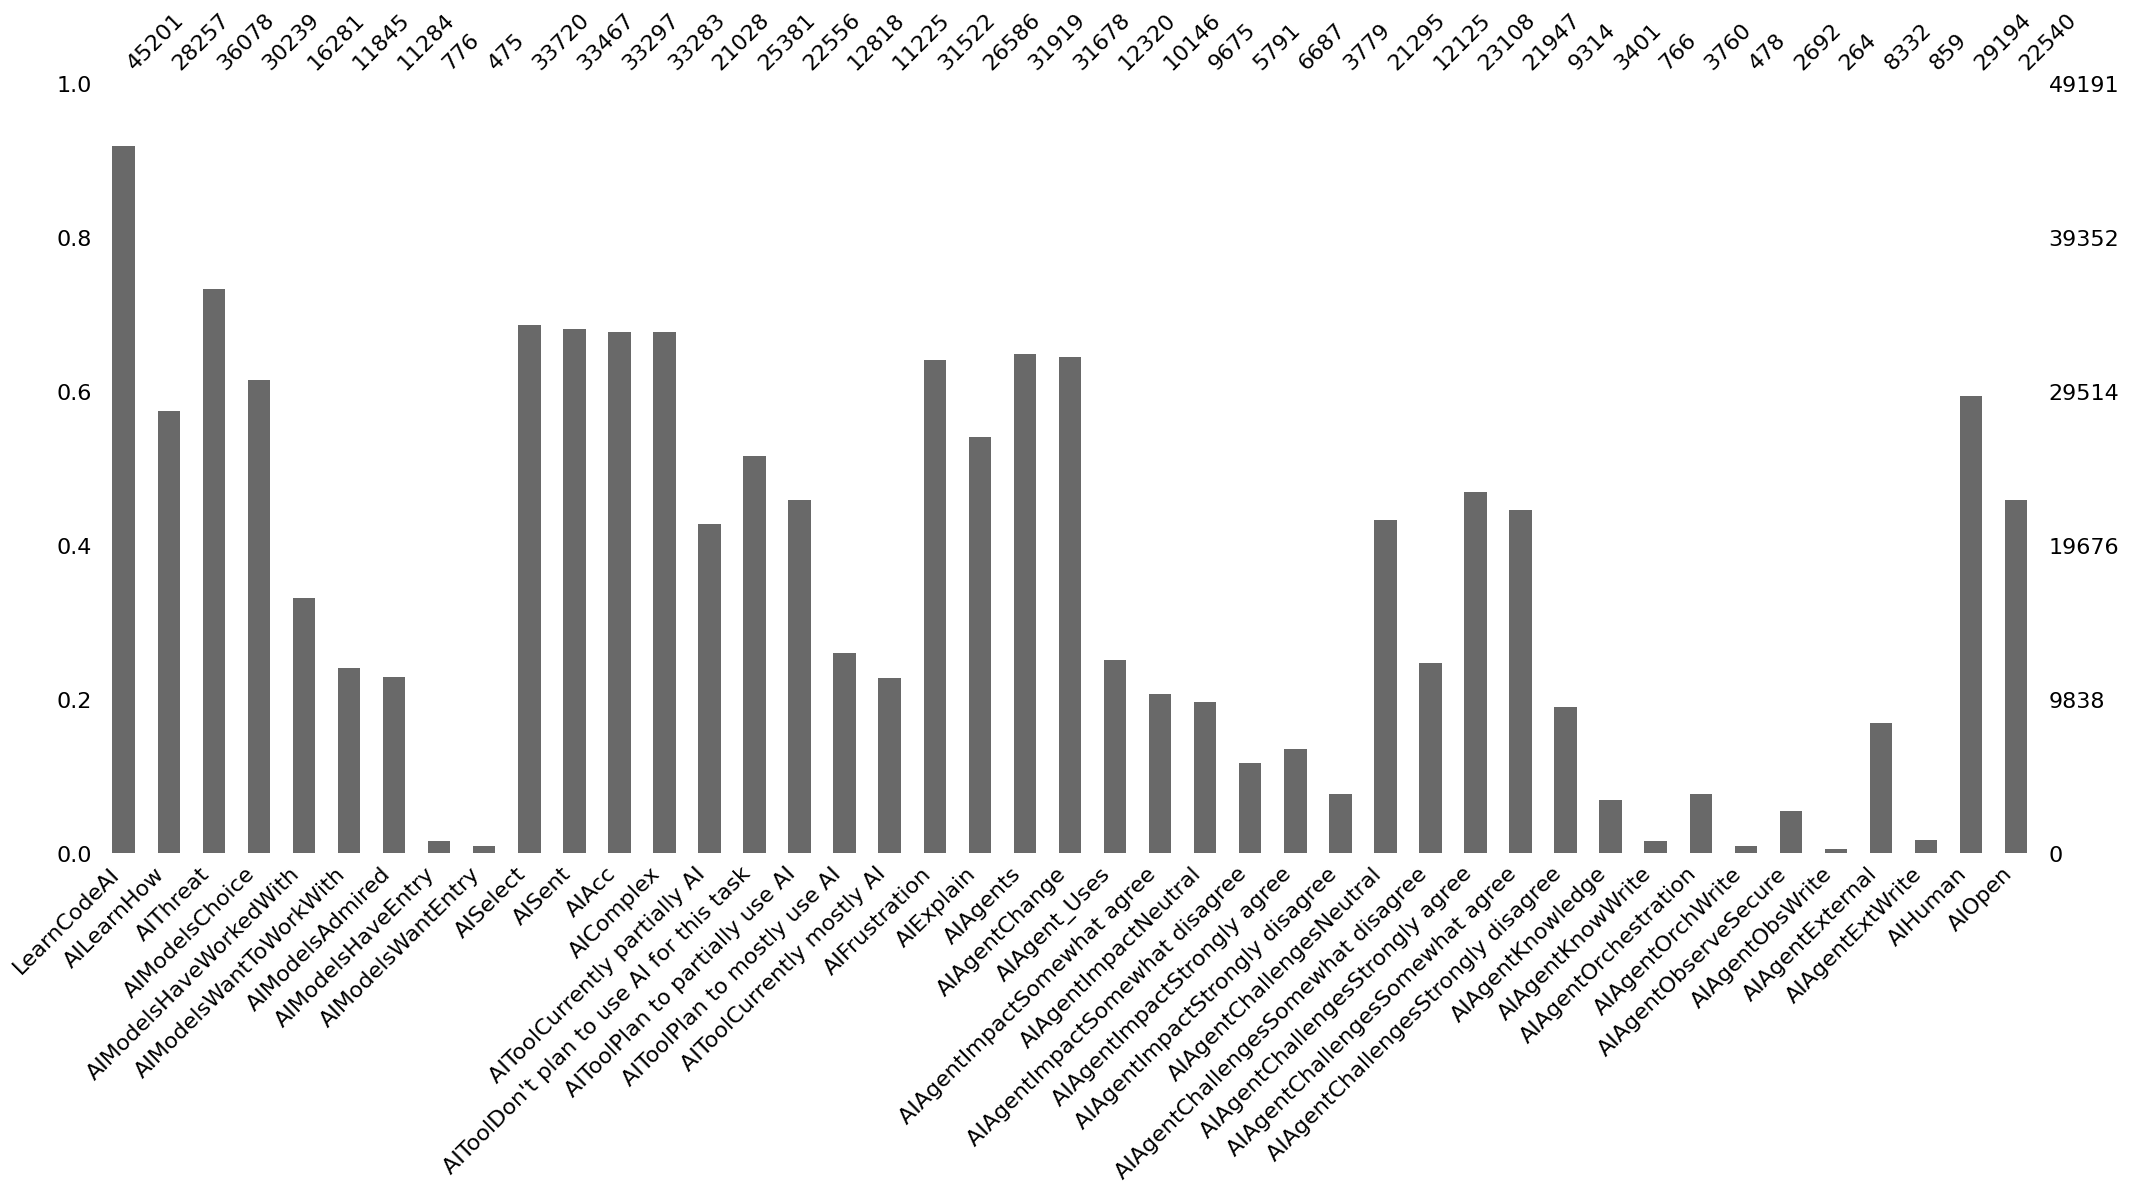

In [14]:
# Response rate of AI related questions
prefix = 'AI'
cols = df_results.filter(like=prefix).columns  # or: df.columns[df.columns.str.startswith(prefix)]
msno.bar(df_results[cols])

In [15]:
# check the number of records with either Currency or CompTotal missing
cols = ["Currency", "CompTotal"]
count = df_results[cols].isna().any(axis=1).sum()
print("Number of records with either one of Currency and CompTotal missing:", count)

# check the number of records with both Currency or CompTotal missing
count = df_results[cols].isna().all(axis=1).sum()
print("Number of records with both Currency and CompTotal missing:", count)

Number of records with either one of Currency and CompTotal missing: 24325
Number of records with both Currency and CompTotal missing: 13754


## Interim findings
-------------------

ConvertedCompYearly has 51.32% of its value missing while CompTotal which ConvertedCompYearly is supposed to be based on has only 49.45% missing.  These additional samll amounts of missing values (1.87%) in ConvertedCompYearly could be due to missing values in the Currency field (even if CompTotal has value or vice versa) or other errors during conversion.

A lot of AI-related questions have low (e.g. less than 30%) response from the participants.  Perhaps a feature can be developed in Sprint 2 to check if there are significant differences in pay between developers who responds to AI vs. those who didn't.

Next we check the distribution of our target prediction value on compensation ConvertedCompYearly.

---


In [16]:
# check if distribution of ConvertedCompYearly in the original, full data set is normal with Shapiro-Wilk test
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    stat, p = shapiro(df_results['ConvertedCompYearly'], nan_policy='omit')     # omit missing values
    print("*** Shapiro-Wilk Test")
    print(f"Statistic: {stat:.4f}, p-value: {p:.4f}")
    if p > 0.05:
        print("Fail to reject null hypothesis - ConvertedCompYearly data looks normal.")
    else:
        print("Reject null hypothesis - ConvertedCompYearly data does not look normal.")

*** Shapiro-Wilk Test
Statistic: 0.0570, p-value: 0.0000
Reject null hypothesis - ConvertedCompYearly data does not look normal.


In [17]:
# check if a random sample of ConvertedCompYearly is normal with Shapiro-Wilk test
sample = np.random.choice(df_results['ConvertedCompYearly'], size=5000, replace=False)
stat5000, p5000 = shapiro(sample, nan_policy='omit')
print("*** Shapiro-Wilk Test")
print(f"Statistic: {stat5000:.4f}, p-value: {p5000:.4f}")
if p5000 > 0.05:
    print("Fail to reject null hypothesis - ConvertedCompYearly data looks normal.")
else:
    print("Reject null hypothesis - ConvertedCompYearly data does not look normal.")

*** Shapiro-Wilk Test
Statistic: 0.0415, p-value: 0.0000
Reject null hypothesis - ConvertedCompYearly data does not look normal.


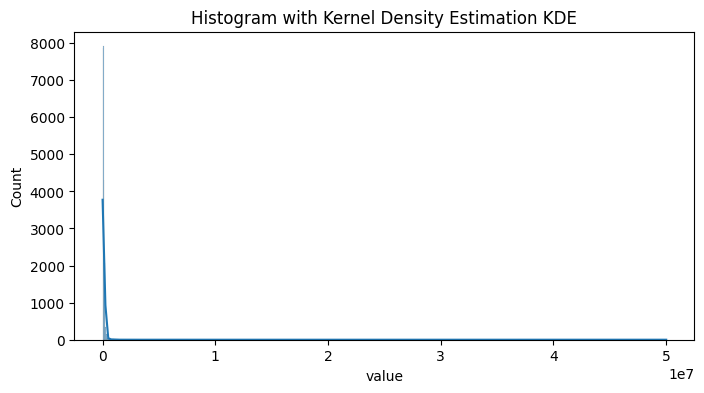

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df_results['ConvertedCompYearly'].dropna(), kde=True, bins=1000)
plt.xlabel('value')
plt.title('Histogram with Kernel Density Estimation KDE')
plt.show()

In [19]:
skew_before = df_results['ConvertedCompYearly'].dropna().skew()
print('skewness:', skew_before)


skewness: 75.50179550127024


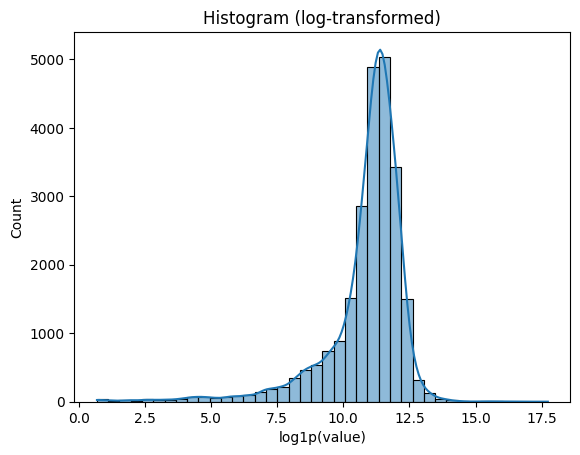

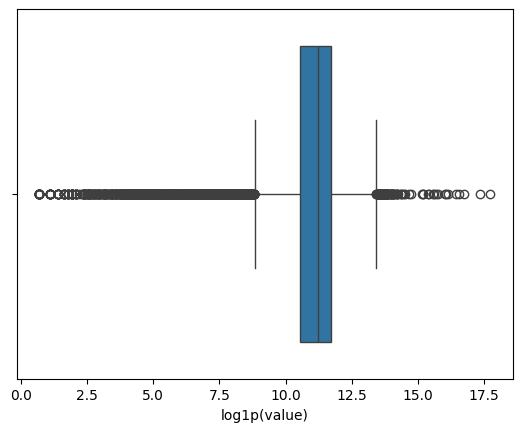

In [20]:
# As data is skewed, log-transforming it before plotting again
x = df_results['ConvertedCompYearly'].dropna()      # remove NaN
x_log1p = np.log1p(x)                               # safe for zeros

# histogram
sns.histplot(x_log1p, kde=True, bins=40)
plt.xlabel('log1p(value)')
plt.title('Histogram (log-transformed)')
plt.show()

# box plot
sns.boxplot(x=x_log1p)
plt.xlabel('log1p(value)')
plt.show()

In [21]:
# recheck skewness
print('skewness after:', pd.Series(x_log1p).skew())

skewness after: -2.502102797256173


In [22]:
# basic stats (on transformed scale)
summary = {
    'n':          x_log1p.size,
    'mean':       x_log1p.mean(),
    'median':     x_log1p.median(),
    'std':        x_log1p.std(ddof=1),
    'min':        x_log1p.min(),
    '25%':        x_log1p.quantile(0.25),
    '75%':        x_log1p.quantile(0.75),
    'max':        x_log1p.max(),
    'skewness':   pd.Series(x_log1p).skew(),
    'kurtosis':   pd.Series(x_log1p).kurtosis()
}
print(summary)

# percentiles
pct = x_log1p.quantile([0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99])
print(pct)

{'n': 23947, 'mean': np.float64(10.847896177484813), 'median': np.float64(11.229514259369093), 'std': np.float64(1.5706763883516917), 'min': np.float64(0.6931471805599453), '25%': np.float64(10.549857541537145), '75%': np.float64(11.700209686793858), 'max': np.float64(17.72753358339242), 'skewness': np.float64(-2.502102797256173), 'kurtosis': np.float64(9.274683842221242)}
0.01     4.189655
0.05     7.910517
0.10     9.062884
0.25    10.549858
0.50    11.229514
0.75    11.700210
0.90    12.122696
0.95    12.354622
0.99    12.996476
Name: ConvertedCompYearly, dtype: float64


In [23]:
# map selected summaries back to the original scale
inv = np.expm1
mapped = {
    'mean_back':    inv(x_log1p.mean()),
    'median_back':  inv(x_log1p.median()),
    '25%_back':     inv(x_log1p.quantile(0.25)),
    '75%_back':     inv(x_log1p.quantile(0.75))
}
print(mapped)

{'mean_back': np.float64(51424.84661487484), 'median_back': np.float64(75319.99999999999), '25%_back': np.float64(38171.00000000003), '75%_back': np.float64(120595.99993366323)}


## Interim finding
------------------

The amount of compensation in the original, full data set collected across the world in 177 countries varies greatly.

Going forward we select only a subset of data that is releavnt to our business question e.g. compensation in the DACH region, with factors that a developer can have agency on.

---

In [24]:
# find the names used for DACH countries in the survey
u = sorted(df_results['Country'].dropna().unique())
print(u)

['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Congo, Republic of the...', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', "Côte d'Ivoire", "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hong Kong (S.A.R.)', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran, Islamic Republic of...', 'Iraq', 'Ireland', 'Isle of Man', 'Israel'

In [25]:
# select rows that are relevant for the business question
# dach region 
mask = df_results['Country'].isin(['Austria','Germany','Switzerland'])
df_dach = df_results[mask]

In [26]:
print(df_dach.describe().to_string())

         ResponseId      WorkExp    YearsCode  TechEndorse_1  TechEndorse_2  TechEndorse_3  TechEndorse_4  TechEndorse_5  TechEndorse_6  TechEndorse_7  TechEndorse_8  TechEndorse_9  TechEndorse_13  TechOppose_1  TechOppose_2  TechOppose_3  TechOppose_5  TechOppose_7  TechOppose_9  TechOppose_11  TechOppose_13  TechOppose_16  TechOppose_15  JobSatPoints_1  JobSatPoints_2  JobSatPoints_3  JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  JobSatPoints_8  JobSatPoints_9  JobSatPoints_10  JobSatPoints_11  JobSatPoints_13  JobSatPoints_14  JobSatPoints_15  JobSatPoints_16  ToolCountWork  ToolCountPersonal       CompTotal  SO_Actions_1  SO_Actions_16  SO_Actions_3  SO_Actions_4  SO_Actions_5  SO_Actions_6  SO_Actions_9  SO_Actions_7  SO_Actions_10  SO_Actions_15  ConvertedCompYearly       JobSat
count   3981.000000  3746.000000  3934.000000    3700.000000    3700.000000    3700.000000    3700.000000    3700.000000    3700.000000    3700.000000    3700.000000    3700.000000     3

In [27]:
# with valid compensation values
mask = df_dach['ConvertedCompYearly'].notna() 
df_dach = df_dach[mask].copy()

In [28]:
print(df_dach.describe().to_string())

         ResponseId     WorkExp    YearsCode  TechEndorse_1  TechEndorse_2  TechEndorse_3  TechEndorse_4  TechEndorse_5  TechEndorse_6  TechEndorse_7  TechEndorse_8  TechEndorse_9  TechEndorse_13  TechOppose_1  TechOppose_2  TechOppose_3  TechOppose_5  TechOppose_7  TechOppose_9  TechOppose_11  TechOppose_13  TechOppose_16  TechOppose_15  JobSatPoints_1  JobSatPoints_2  JobSatPoints_3  JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  JobSatPoints_8  JobSatPoints_9  JobSatPoints_10  JobSatPoints_11  JobSatPoints_13  JobSatPoints_14  JobSatPoints_15  JobSatPoints_16  ToolCountWork  ToolCountPersonal       CompTotal  SO_Actions_1  SO_Actions_16  SO_Actions_3  SO_Actions_4  SO_Actions_5  SO_Actions_6  SO_Actions_9  SO_Actions_7  SO_Actions_10  SO_Actions_15  ConvertedCompYearly       JobSat
count   2839.000000  2792.00000  2826.000000    2684.000000    2684.000000    2684.000000    2684.000000    2684.000000    2684.000000    2684.000000    2684.000000    2684.000000     268

In [29]:
# find values defining a professional developer
u = sorted(df_results['MainBranch'].dropna().unique())
print(u)

['I am a developer by profession', 'I am learning to code', 'I am not primarily a developer, but I write code sometimes as part of my work/studies', 'I code primarily as a hobby', 'I used to be a developer by profession, but no longer am', 'I work with developers or my work supports developers but am not a developer by profession']


In [30]:
# professional developers only
mask = (df_dach['MainBranch'] == 'I am a developer by profession') 
df_dach = df_dach[mask].copy()

In [31]:
print(df_dach.describe().to_string())

         ResponseId      WorkExp    YearsCode  TechEndorse_1  TechEndorse_2  TechEndorse_3  TechEndorse_4  TechEndorse_5  TechEndorse_6  TechEndorse_7  TechEndorse_8  TechEndorse_9  TechEndorse_13  TechOppose_1  TechOppose_2  TechOppose_3  TechOppose_5  TechOppose_7  TechOppose_9  TechOppose_11  TechOppose_13  TechOppose_16  TechOppose_15  JobSatPoints_1  JobSatPoints_2  JobSatPoints_3  JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  JobSatPoints_8  JobSatPoints_9  JobSatPoints_10  JobSatPoints_11  JobSatPoints_13  JobSatPoints_14  JobSatPoints_15  JobSatPoints_16  ToolCountWork  ToolCountPersonal       CompTotal  SO_Actions_1  SO_Actions_16  SO_Actions_3  SO_Actions_4  SO_Actions_5  SO_Actions_6  SO_Actions_9  SO_Actions_7  SO_Actions_10  SO_Actions_15  ConvertedCompYearly       JobSat
count   2343.000000  2327.000000  2335.000000    2210.000000    2210.000000    2210.000000    2210.000000    2210.000000    2210.000000    2210.000000    2210.000000    2210.000000     2

In [32]:
# find values defining active employment at the time when filling in the survey
u = sorted(df_results['Employment'].dropna().unique())
print(u)

['Employed', 'I prefer not to say', 'Independent contractor, freelancer, or self-employed', 'Not employed', 'Retired', 'Student']


In [33]:
# was employed when filling out the survey
mask = df_dach['Employment'].isin(['Employed','Independent contractor, freelancer, or self-employed'])
df_dach = df_dach[mask].copy()

In [34]:
print(df_dach.describe().to_string())

         ResponseId      WorkExp    YearsCode  TechEndorse_1  TechEndorse_2  TechEndorse_3  TechEndorse_4  TechEndorse_5  TechEndorse_6  TechEndorse_7  TechEndorse_8  TechEndorse_9  TechEndorse_13  TechOppose_1  TechOppose_2  TechOppose_3  TechOppose_5  TechOppose_7  TechOppose_9  TechOppose_11  TechOppose_13  TechOppose_16  TechOppose_15  JobSatPoints_1  JobSatPoints_2  JobSatPoints_3  JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  JobSatPoints_8  JobSatPoints_9  JobSatPoints_10  JobSatPoints_11  JobSatPoints_13  JobSatPoints_14  JobSatPoints_15  JobSatPoints_16  ToolCountWork  ToolCountPersonal       CompTotal  SO_Actions_1  SO_Actions_16  SO_Actions_3  SO_Actions_4  SO_Actions_5  SO_Actions_6  SO_Actions_9  SO_Actions_7  SO_Actions_10  SO_Actions_15  ConvertedCompYearly       JobSat
count   2226.000000  2216.000000  2218.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000     2

In [35]:
print(df_dach.head(10).to_string())

     ResponseId                      MainBranch              Age                                                                             EdLevel Employment                               EmploymentAddl  WorkExp                                                                              LearnCodeChoose                                                                                                                                                                                                                                                                                                                                                                LearnCode                                                                                                         LearnCodeAI                                                                                                                                                                                                                         

In [36]:
# 
# the following code will remove additional invalid data other than those in the ConvertedCompYearly column, 
# this will reduce the number of responses further from 2226 to 1625 only  
#
# mask = (df_dach['WorkExp'].between(1,50)) & (df_dach['YearsCode'].between(1,50)) & (df_dach['ToolCountWork'].between(1,200)) & (df_dach['ToolCountPersonal'].between(1,200))
# df_dach = df_dach[mask].copy()

## Interim finding
------------------

As of now the data frame df_dach contains only responses from DACH region professional developers who were employed or self-employed during the survey.

As removing rows with questionable values in non-target columns at this stage will further reduce the data set from 2226 to 1625 records, these rows will not be removed for now.  We should look into methods to imputate them in Sprint 2.

Next step is to select columns that are relevant to our business question only.

---


In [37]:
print(df_dach.describe().to_string())

         ResponseId      WorkExp    YearsCode  TechEndorse_1  TechEndorse_2  TechEndorse_3  TechEndorse_4  TechEndorse_5  TechEndorse_6  TechEndorse_7  TechEndorse_8  TechEndorse_9  TechEndorse_13  TechOppose_1  TechOppose_2  TechOppose_3  TechOppose_5  TechOppose_7  TechOppose_9  TechOppose_11  TechOppose_13  TechOppose_16  TechOppose_15  JobSatPoints_1  JobSatPoints_2  JobSatPoints_3  JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  JobSatPoints_8  JobSatPoints_9  JobSatPoints_10  JobSatPoints_11  JobSatPoints_13  JobSatPoints_14  JobSatPoints_15  JobSatPoints_16  ToolCountWork  ToolCountPersonal       CompTotal  SO_Actions_1  SO_Actions_16  SO_Actions_3  SO_Actions_4  SO_Actions_5  SO_Actions_6  SO_Actions_9  SO_Actions_7  SO_Actions_10  SO_Actions_15  ConvertedCompYearly       JobSat
count   2226.000000  2216.000000  2218.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000    2097.000000     2

In [38]:
print(df_dach.head(10).to_string())

     ResponseId                      MainBranch              Age                                                                             EdLevel Employment                               EmploymentAddl  WorkExp                                                                              LearnCodeChoose                                                                                                                                                                                                                                                                                                                                                                LearnCode                                                                                                         LearnCodeAI                                                                                                                                                                                                                         

In [39]:
# select columns that are relevant to the business question stated at the beginning of this notebook
#
# MainBranch    - professional developer only
# EdLevel       - all, one hypothesis is the higher the education level, the higher the compensation
# Employment    - employed and working people only
# OrgSize       - the bigger the firm the higher the paid?
# ...
#
cols = ['MainBranch','Age','EdLevel','Employment','WorkExp','LearnCodeChoose','LearnCode','LearnCodeAI','AILearnHow','YearsCode',
        'DevType','OrgSize','ICorPM','RemoteWork','PurchaseInfluence','Industry','Country','Currency','CompTotal','LanguageChoice',
        'LanguageHaveWorkedWith','DatabaseChoice','DatabaseHaveWorkedWith','PlatformChoice','PlatformHaveWorkedWith','WebframeChoice',
        'WebframeHaveWorkedWith','AIModelsChoice','DevEnvsChoice','DevEnvsHaveWorkedWith','AIModelsHaveWorkedWith','AISelect','AIAgents',
        'AIAgent_Uses','ConvertedCompYearly','JobSat']
df_dach = df_dach[cols].copy()

In [40]:
print(df_dach.head(10).to_string())

                         MainBranch              Age                                                                             EdLevel Employment  WorkExp                                                                              LearnCodeChoose                                                                                                                                                                                                                                                                                                                                                                LearnCode                                                                                                         LearnCodeAI                                                                                                                                                                                                                                                                                  

In [41]:
print(df_dach.tail(10).to_string())

                           MainBranch              Age                                                 EdLevel                                            Employment  WorkExp                                                                              LearnCodeChoose                                                                                                                                                                                                                                                                                                                  LearnCode                                                                             LearnCodeAI                                                                                                                                                                                                                                                                   AILearnHow  YearsCode                          DevType                  

## Interim findings
-------------------

Other than columns showing demographics, only columns related to factors which a developer can actively decide or act on are being selected as part of the more focused data set:

- MainBranch              - job as a professional developer
- EdLevel                 - highest education level
- LearnCodeChoose         - studied a new language or not during the last year despite not new to coding
- LearnCode               - method used to learn the new language
- LearnCodeAI             - studied AI or not during the last year
- AILearnHow              - method used to learn AI
- DevType                 - the specific job role inside the professional developer profession
- OrgSize                 - works for big company or smaller ones
- ICorPM                  - works as an individual contributor or one with responsibility over others 
- RemoteWork              - works remotely or onsite
- PurchaseInfluence       - influences purchasing or not
- Industry                - industry worked in
- LanguageChoice          - programs, or not?
- LanguageHaveWorkedWith  - which languages
- DatabaseChoice          - works with databases, or not?
- DatabaseHaveWorkedWith  - which databases
- PlatformChoice          - works with platforms such as clouds, containers etc., or not?
- PlatformHaveWorkedWith  - which platforms
- WebframeChoice          - works with web frameworks, or not?
- WebframeHaveWorkedWith  - which frameworks
- DevEnvsChoice           - works with development environments (AI or not) worked with
- DevEnvsHaveWorkedWith   - which environments?
- AIModelsChoice          - works with AI LLMs, or not
- AIModelsHaveWorkedWith  - which LLMs?
- AISelect                - uses AI tools in development process (semi-automatic)?
- AIAgents                - uses AI agents in development process (highly automatic)?
- AIAgent_Uses            - uses AI agents for what processes?
- JobSat                  - satisfied with your job?

The above is partly inspired by an earlier iteration of the EDA in another notebook, in which ydata-profiling was done against the entire, original data set.  According to that run (see https://github.com/STetiana/stackoverflow_buddies/wiki/05-Hypothesis at the very bottom), compensation is highly correlated with some of the columns above.

Other columns are excluded because they are not being perceived as tangible actions or decisions that will influence the capability and marketability of a developer.  Examples are attitude and personal prediction (insetad of tangible actions) towards AI and other technologies, the operating system used to develop code, the usage of Stack Overflow etc.

Next is to check how the resultant data set looks like in terms of distribution, missing values etc.

---

In [42]:
print(df_dach.describe().to_string())

           WorkExp    YearsCode       CompTotal  ConvertedCompYearly       JobSat
count  2216.000000  2218.000000     2226.000000         2.226000e+03  2153.000000
mean     13.197653    18.921100    83836.031447         9.847865e+04     7.019972
std       9.011841     9.873562    54027.875874         6.429372e+04     1.939386
min       1.000000     2.000000        2.000000         2.000000e+00     0.000000
25%       6.000000    11.000000    58000.000000         6.728900e+04     6.000000
50%      11.000000    17.000000    75500.000000         8.817100e+04     7.000000
75%      18.000000    25.000000   100000.000000         1.160150e+05     8.000000
max     100.000000   100.000000  1000000.000000         1.160147e+06    10.000000


In [43]:
# Check the number of missing values in the DACH dataset, and list them in percentage
print("*** Missing values in percentage")
print((df_dach.isnull().mean() * 100).round(2).to_string())

*** Missing values in percentage
MainBranch                 0.00
Age                        0.00
EdLevel                    0.04
Employment                 0.00
WorkExp                    0.45
LearnCodeChoose            0.09
LearnCode                 32.12
LearnCodeAI                0.22
AILearnHow                36.16
YearsCode                  0.36
DevType                    0.00
OrgSize                    6.06
ICorPM                     7.55
RemoteWork                 6.29
PurchaseInfluence          0.13
Industry                   0.13
Country                    0.00
Currency                   0.00
CompTotal                  0.00
LanguageChoice             3.77
LanguageHaveWorkedWith     4.76
DatabaseChoice             4.90
DatabaseHaveWorkedWith    20.22
PlatformChoice             5.66
PlatformHaveWorkedWith    20.44
WebframeChoice             6.02
WebframeHaveWorkedWith    27.90
AIModelsChoice             8.36
DevEnvsChoice              6.33
DevEnvsHaveWorkedWith     17.65
AIModel

<Axes: >

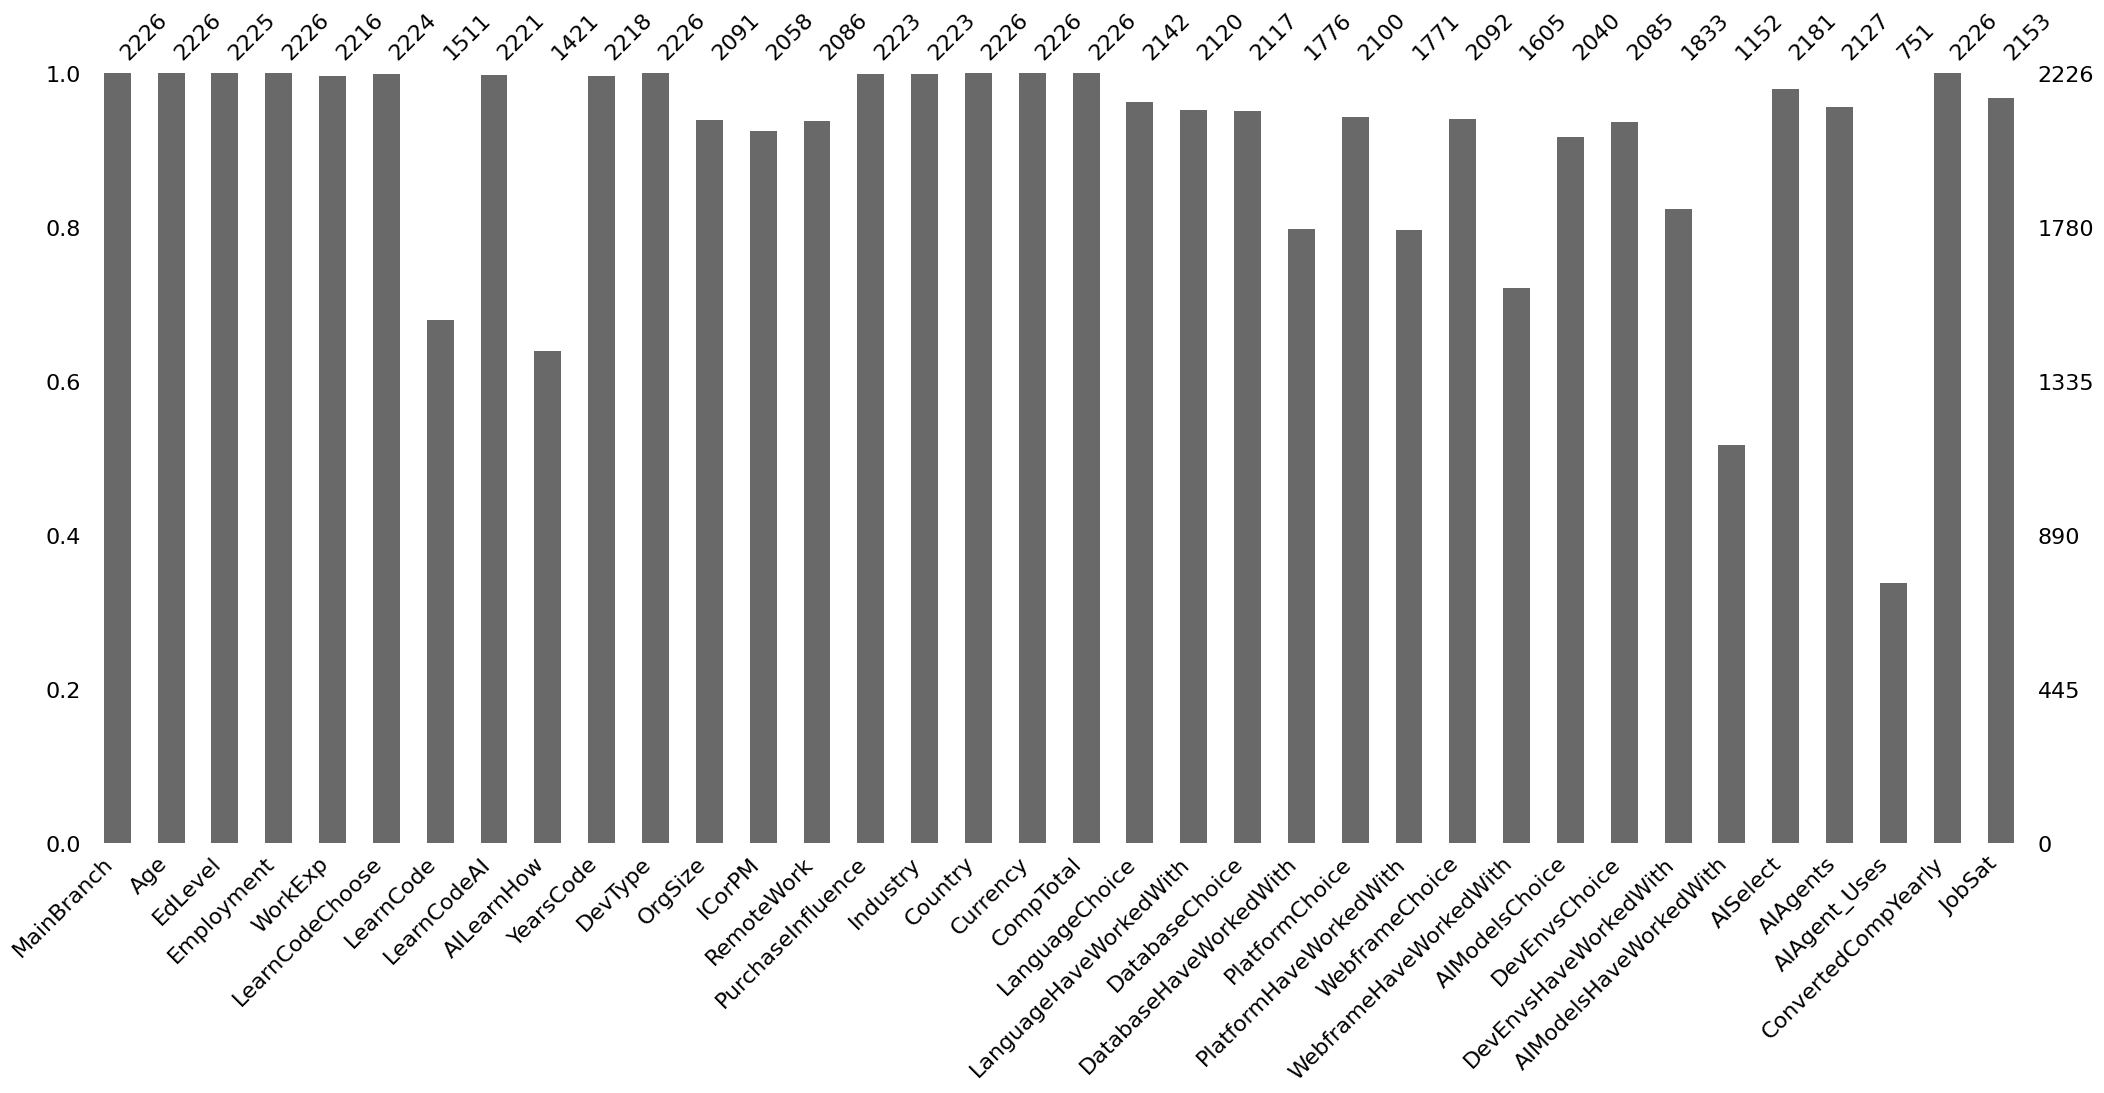

In [44]:
# summary bar showing rows with response in percentage (on top) and in absolute number (at the right) for the DACH region
msno.bar(df_dach)

## Interim findings
-------------------

There are substantially less missing values in responses relevant to our business question, making the data set more usable despite the smaller number of rows.

Next we check the distribution of the target prediction value for compensation ConvertedCompYearly.

---

In [45]:
# check if distribution of ConvertedCompYearly in the DACH data set is normal with Shapiro-Wilk test
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    stat, p = shapiro(df_dach['ConvertedCompYearly'], nan_policy='omit')     # omit missing values
    print("*** Shapiro-Wilk Test")
    print(f"Statistic: {stat:.4f}, p-value: {p:.4f}")
    if p > 0.05:
        print("Fail to reject null hypothesis - ConvertedCompYearly data looks normal.")
    else:
        print("Reject null hypothesis - ConvertedCompYearly data does not look normal.")

*** Shapiro-Wilk Test
Statistic: 0.6648, p-value: 0.0000
Reject null hypothesis - ConvertedCompYearly data does not look normal.


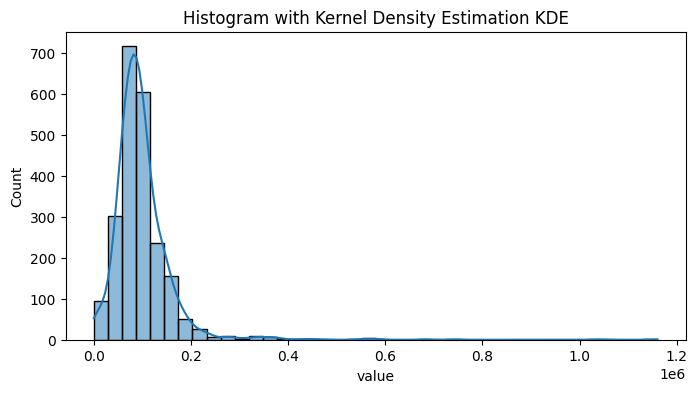

In [46]:
plt.figure(figsize=(8,4))
sns.histplot(df_dach['ConvertedCompYearly'].dropna(), kde=True, bins=40)
plt.xlabel('value')
plt.title('Histogram with Kernel Density Estimation KDE')
plt.show()

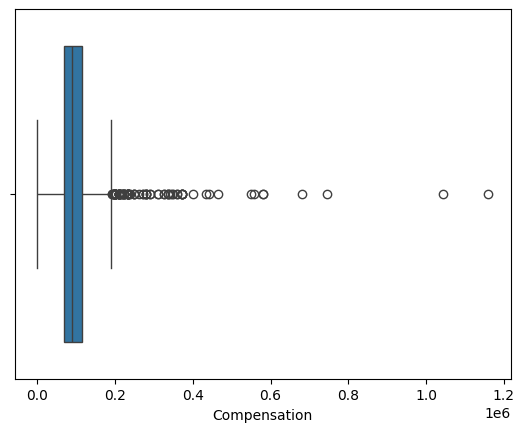

In [47]:
# box plot
sns.boxplot(x=df_dach['ConvertedCompYearly'])
plt.xlabel('Compensation')
plt.show()

In [48]:
skew_before = df_dach['ConvertedCompYearly'].dropna().skew()
print('skewness:', skew_before)

skewness: 5.801354991806638


## Interim findings
-------------------

The compensation in DACH region is also unevenly distributed, with a long tail of outliers towards the higher compensation end.

Next is to get a comprehensive profiling on the remaining columns using ydata-profiling for the reduced DACH professional developer with employment data set.

The result is stored in a separate HTML file called sprint01_eda_profile_report.html.

---


In [49]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    profile = ProfileReport(df_dach, title="Profile Report - Stackoverflow Survey Results 2025 - DACH Professional Developers in Employment")
    report_file = data_path.joinpath("sprint01_eda_profile_report.html")
    profile.to_file(report_file)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:00<00:00, 104.10it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Interim findings
-------------------

In an earlier iteration of the EDA in another notebook, I ran ydata-profiling against the entire, original data set.  

According to that run (see https://github.com/STetiana/stackoverflow_buddies/wiki/05-Hypothesis at the very bottom), compensation is highly correlated with:

- DatabaseChoice
- DevEnvsChoice
- AIModelsChoice
- PlatformChoice
- WebFrameChoice
- Industry
- ICorPM
- PurchaseInfluence
- RemoteWork

Such high correlation could not be found in the reduced DACH professional developer with employment data set anymore.

To check if removing the long tail of high compensation help in uncovering other patterns, we will reduce further our data set to 75 percentile in the next step and rerun ydata-profiling again.

---


In [50]:
low, high = df_dach['ConvertedCompYearly'].quantile(0.125), df_dach['ConvertedCompYearly'].quantile(0.875)
central75 = df_dach.loc[df_dach['ConvertedCompYearly'].between(low, high)].copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    profile = ProfileReport(central75, title="Profile Report - Stackoverflow Survey Results 2025 - DACH Professional Developers in Employment (Central 75 Percentile Compensation)")
    report_file = data_path.joinpath("sprint01_eda_profile_report_75.html")
    profile.to_file(report_file)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:00<00:00, 93.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Interim findings
-------------------

Focusing on the central 75 percentile as an attempt to skip the shewed long tail of high compensation numbers does not reveal those high correlations found in the original, full data set neither.  The results of this run is stored in a separate HTML file called sprint01_eda_profile_report_75.html.

As an interim conclusion, it can be said that correlations shown in a big data set assembled over highly different real world situations may not apply to a specific geography or market.

On the other hand instead of discounting the long tail of outliers, perhaps they should be studied to see if they point to some secret sauce to high compensation.  Correlation between individual columns and compensation should also be looked at again using tools other than ydata-profiling (Target: Tuesday 14.03.2026 10:00).

---